# Model 7 — Fuel Consumption Predictor (Linear Regression)

## Question
> Given a car's engine size, weight, body type, and drivetrain — what average fuel consumption should I expect in L/100km?

## Introduction
This notebook builds a **linear regression model** to predict average fuel consumption.

- **Dataset**: Unscaled data (`proceed_dataset_without_scaling.csv`)
- **Target variable**: `Ort. Yakıt Tüketimi` (average fuel consumption in L/100km)
- **Required algorithm**: You must use a **linear model** — `LinearRegression`, `Ridge`, or `Lasso`. Tree-based or ensemble methods are **not allowed** for this task.
- **Feature flexibility**: You may choose different features, add new features, or tune hyperparameters — but you cannot change the general technique category (linear regression).

### 1. Data Import

The cell below loads all required libraries and the dataset. **Run this cell as-is** — it is provided and complete.

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

df = pd.read_csv('https://raw.githubusercontent.com/MamoMGD1/ISE302-DataMining-GroupProject/main/data/proceed_dataset_without_scaling.csv')
print(f"Dataset shape: {df.shape}")

# Check target column availability
target_col = 'Ort. Yakıt Tüketimi'
if target_col in df.columns:
    print(f"Target column '{target_col}': {df[target_col].notna().sum()} non-null values")
    print(f"Range: {df[target_col].min():.1f} — {df[target_col].max():.1f} L/100km")
else:
    print(f"WARNING: Target column '{target_col}' not found. Check column names.")
    print(f"Available columns containing 'Yakıt': {[c for c in df.columns if 'Yakıt' in c]}")
df.head()

Dataset shape: (2589, 87)
Target column 'Ort. Yakıt Tüketimi': 2589 non-null values
Range: 3.8 — 13.4 L/100km


,Fiyat,Yıl,Kilometre,İlan Tarihi,Ortalama Kasko,Ortalama Trafik Sigortası,Üretim Yılı (İlk/Son),Silindir Sayısı,Koltuk Sayısı,Bagaj Hacmi,...,Hızlanma (0-100),Maksimum Hız,Uzunluk,Genişlik,Yükseklik,Ağırlık,Boş Ağırlığı,Aks Aralığı,Jant Boyutu,log_Fiyat
0,2425000,2025,6001,0.507585,9.730597,9.436162,2024.524726,3,5,6.255935,...,10.1,198.0,8.388223,1806.0,1590.0,7.530480,1315.0,7.881182,17,14.701342
1,2900000,2025,16000,0.540567,9.801196,9.426602,2024.561718,4,5,6.312241,...,9.2,199.0,8.395252,1848.0,1625.0,7.591862,1450.0,7.888335,19,14.880222
2,1150000,2015,265000,0.437396,9.847922,9.310729,2015.500000,4,5,5.996452,...,12.4,180.0,8.384804,1800.0,1590.0,7.555382,1365.0,7.881182,19,13.955273
3,1240000,2014,196000,0.403619,9.796904,9.310729,2015.500000,4,5,5.996452,...,10.7,182.0,8.384804,1800.0,1590.0,7.603898,1461.0,7.881182,17,14.030623
4,690000,2011,305000,0.354720,9.696057,9.341037,2011.476979,4,5,6.115519,...,12.2,174.0,8.370084,1780.0,1615.0,7.565793,1407.0,7.875119,16,13.444448


### 2. Feature Selection

**TODO — Student task:** Review the recommended features below. You may keep them, remove some, or add others from the dataset. After finalizing your features, run this cell to prepare training and test sets.

In [24]:
# TODO: Select your features. Recommended starting set:
recommended_features = [
    'Motor Hacmi', 'Ağırlık', 'Motor Gücü', 'Kasa Tipi_SUV',
    'Yakıt Tipi_Hibrit', 'Çekiş_AWD (Elektronik)',
    'Boş Ağırlığı', 'Silindir Sayısı', 'Yükseklik', 'Tork'
]
target = 'Ort. Yakıt Tüketimi'

features = [f for f in recommended_features if f in df.columns]

# Drop rows where target is missing
df_model = df[features + [target]].dropna(subset=[target])
X = df_model[features].fillna(df_model[features].median())
y = df_model[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Training set: {X_train.shape}, Test set: {X_test.shape}")
print(f"Target range (train): {y_train.min():.1f} — {y_train.max():.1f} L/100km")

Training set: (2071, 10), Test set: (518, 10)
Target range (train): 3.8 — 13.4 L/100km


### 3. Model Training

**TODO — Student task:** This cell is a placeholder. The structure (instantiate → fit → predict) is correct — you may change the model type or add hyperparameters. Do **not** use tree-based or ensemble methods.

In [25]:
from sklearn.linear_model import LinearRegression  # You may also try Ridge or Lasso

# TODO: You may replace LinearRegression with Ridge(alpha=...) or Lasso(alpha=...)
# Do NOT use tree-based or ensemble methods.
model = LinearRegression()

model.fit(X_train, y_train)
y_pred = model.predict(X_test)
print("Linear Regression model trained.")

Linear Regression model trained.


### 4. Evaluation Metrics

The cell below computes RMSE, MAE, and R² on the test set. These are the primary metrics for your report.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

In [26]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.3f} L/100km")
print(f"MAE:  {mae:.3f} L/100km")
print(f"R²:   {r2:.4f}")

RMSE: 0.687 L/100km
MAE:  0.493 L/100km
R²:   0.7098


### 5. Actual vs Predicted Scatter Plot

This scatter plot compares actual fuel consumption values with your model's predictions. Points close to the red diagonal line indicate accurate predictions.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

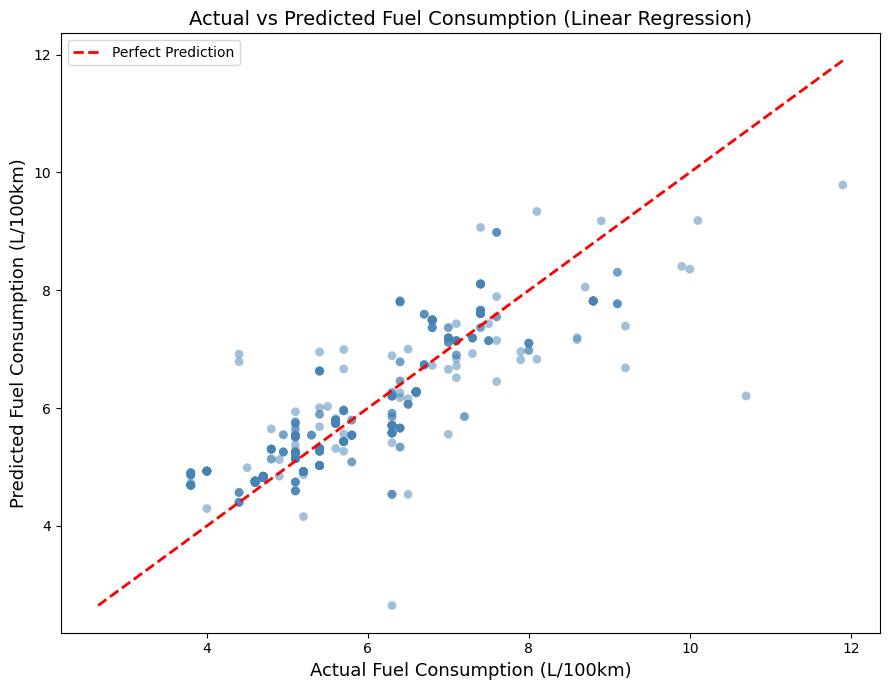

In [27]:
# ⚠️ Replace y_test and y_pred with your actual outputs after training.
fig, ax = plt.subplots(figsize=(9, 7))
ax.scatter(y_test, y_pred, alpha=0.5, color='steelblue', s=40, edgecolors='none')
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
ax.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect Prediction')
ax.set_xlabel('Actual Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_title('Actual vs Predicted Fuel Consumption (Linear Regression)', fontsize=14)
ax.legend()
plt.tight_layout()
plt.show()

### 6. Residual Plot — Check for Heteroscedasticity

This plot shows the residuals (actual − predicted) against predictions. A random scatter around 0 indicates a well-fitting model. Patterns or funnels suggest heteroscedasticity.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

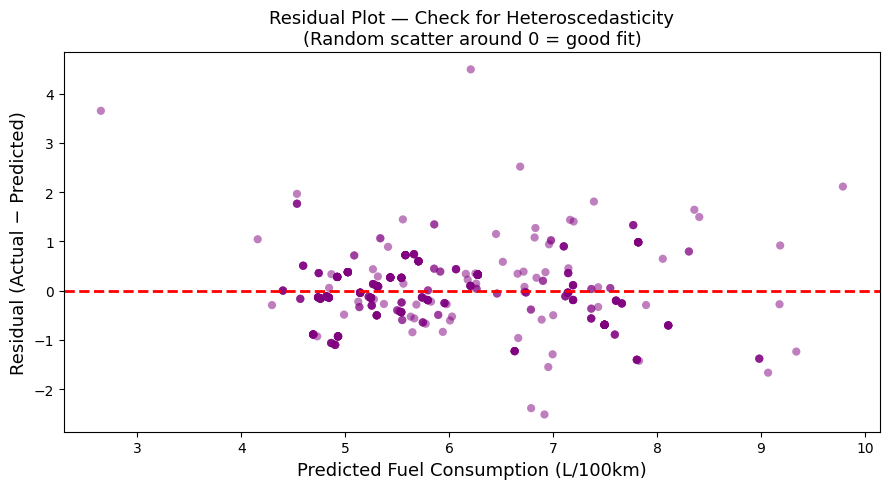

In [28]:
# ⚠️ Replace y_pred with your actual outputs after training.
residuals = y_test - y_pred
fig, ax = plt.subplots(figsize=(9, 5))
ax.scatter(y_pred, residuals, alpha=0.5, color='purple', s=35, edgecolors='none')
ax.axhline(0, color='red', linestyle='--', linewidth=2)
ax.set_xlabel('Predicted Fuel Consumption (L/100km)', fontsize=13)
ax.set_ylabel('Residual (Actual − Predicted)', fontsize=13)
ax.set_title('Residual Plot — Check for Heteroscedasticity\n(Random scatter around 0 = good fit)', fontsize=13)
plt.tight_layout()
plt.show()

### 7. Feature Coefficients

This bar chart shows the learned coefficients for each feature. Red bars indicate features that increase fuel consumption; green bars indicate features that decrease it.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

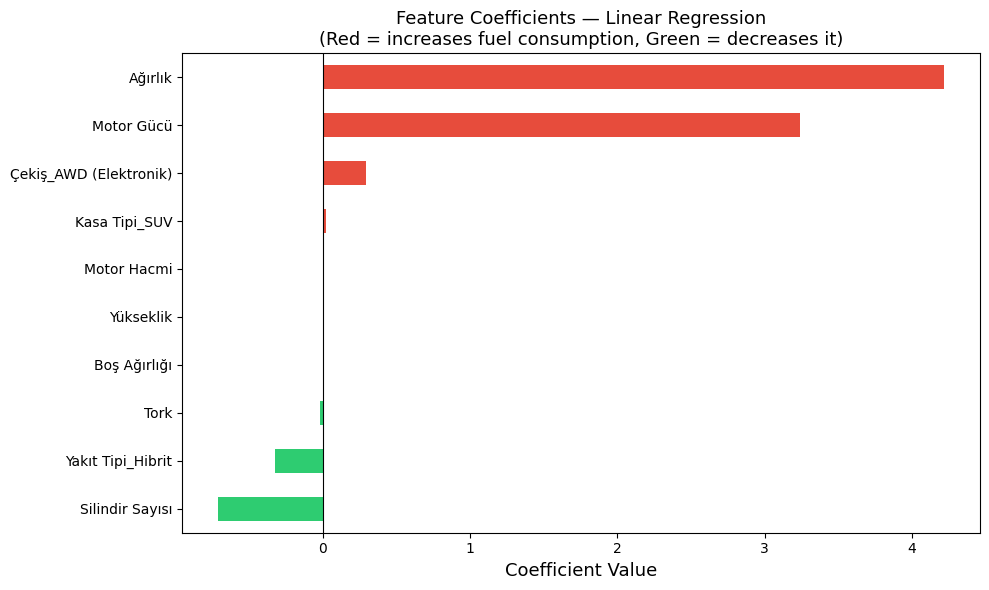

In [29]:
# ⚠️ Replace model and features with your actual trained model after training.
coef_series = pd.Series(model.coef_, index=features).sort_values()
colors = ['#e74c3c' if c > 0 else '#2ecc71' for c in coef_series.values]

fig, ax = plt.subplots(figsize=(10, 6))
coef_series.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Coefficient Value', fontsize=13)
ax.set_title('Feature Coefficients — Linear Regression\n(Red = increases fuel consumption, Green = decreases it)', fontsize=13)
plt.tight_layout()
plt.show()

### 8. Hybrid vs Non-Hybrid Predicted Consumption

This bar chart compares the average predicted fuel consumption for hybrid vs non-hybrid cars in the test set, directly answering a key business question.

> ⚠️ This cell uses placeholder data for illustration. Replace with your actual model outputs after training.

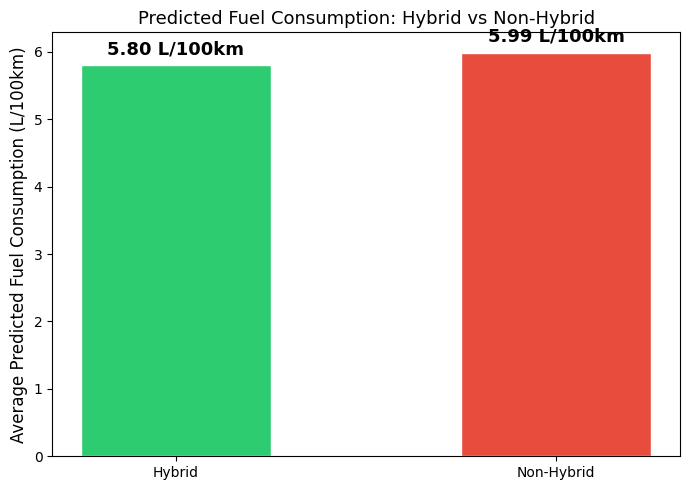

In [30]:
# ⚠️ Replace model with your actual trained model after training.
if 'Yakıt Tipi_Hibrit' in features:
    hybrid_mask = X_test['Yakıt Tipi_Hibrit'] == 1
    non_hybrid_mask = X_test['Yakıt Tipi_Hibrit'] == 0

    avg_hybrid = y_pred[hybrid_mask].mean() if hybrid_mask.sum() > 0 else 0
    avg_non_hybrid = y_pred[non_hybrid_mask].mean() if non_hybrid_mask.sum() > 0 else 0

    fig, ax = plt.subplots(figsize=(7, 5))
    bars = ax.bar(['Hybrid', 'Non-Hybrid'], [avg_hybrid, avg_non_hybrid],
                  color=['#2ecc71', '#e74c3c'], edgecolor='white', width=0.5)
    for bar, val in zip(bars, [avg_hybrid, avg_non_hybrid]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                f'{val:.2f} L/100km', ha='center', va='bottom', fontsize=13, fontweight='bold')
    ax.set_ylabel('Average Predicted Fuel Consumption (L/100km)', fontsize=12)
    ax.set_title('Predicted Fuel Consumption: Hybrid vs Non-Hybrid', fontsize=13)
    plt.tight_layout()
    plt.show()
else:
    print("'Yakıt Tipi_Hibrit' not in features. Skipping comparison.")

## ⚠️ If Your Model Underperforms

If your model produces poor results (e.g., low R², large RMSE, or coefficients that don't make physical sense), **do not discard your results**.

- Keep all outputs as-is
- In your presentation, document exactly what you observe
- Write a short hypothesis: Why might the model have failed? (e.g., 'Fuel consumption may have a non-linear relationship with some features, or multicollinearity between engine size and power may have inflated coefficient variance')